In [1]:
import math
import pandas as pd


DB_PATH = "runs_index.csv"

DB = pd.read_csv(DB_PATH, index_col=0)


PROBLEMS = ['vanderpol', 'pollu', 'rober', 'orego', 'hires', 'davis-skodje']
PRETRAINING_OPTIONS = ['derivmatch', 'none']
TRAINING_OPTIONS = ['shooting', 'collocation', 'none']
SEED_OPTIONS = list(range(600, 610))  # seeds from 600 to 609 inclusive

# Remove rows where seed is not between 10 and 20 (inclusive)
DB = DB[(DB['seed'] >= 600) & (DB['seed'] <= 609)]

DB.info()
# 20 seeds, 2 problems, 2 training options, 2 architecture options

<class 'pandas.core.frame.DataFrame'>
Index: 79 entries, run_04JNjKl1 to run_zwr1UIBJ
Data columns (total 49 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   E_VF_species_test           79 non-null     object 
 1   E_VF_species_train          79 non-null     object 
 2   E_VF_test                   71 non-null     float64
 3   E_VF_train                  79 non-null     float64
 4   E_spec_species_test         79 non-null     object 
 5   E_spec_species_train        79 non-null     object 
 6   E_spec_test                 71 non-null     float64
 7   E_spec_train                79 non-null     float64
 8   E_trajectory_species_test   79 non-null     object 
 9   E_trajectory_species_train  79 non-null     object 
 10  E_trajectory_test           71 non-null     float64
 11  E_trajectory_train          79 non-null     float64
 12  collocation_time            79 non-null     float64
 13  computer             

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
FIG_DIR = REPO_ROOT / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10.5,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Colorblind-safe roles (same categorical slots used elsewhere in analysis/).
COLOR_DERIVMATCH = "#8a8a8a"    # pointwise pretraining baseline -- no ODE solve
COLOR_COLLOCATION = "#2a78d6"   # simultaneous implicit system -- not expected to decay
COLOR_SHOOTING = "#eb6834"      # forward-integrate + backprop -- the paper's vulnerable case
STAGE_COLOR = {"derivmatch": COLOR_DERIVMATCH, "collocation": COLOR_COLLOCATION, "shooting": COLOR_SHOOTING}
STAGE_ORDER = ["derivmatch", "collocation", "shooting"]
MODEL_MARKER = {"stiff": "o", "GELU-scaled": "s"}

In [3]:
# sensitivity_by_stage is written per run by --track-sensitivity (run_main.jl) and
# extracted from every run's state.jld2 into one long-format CSV by
# src/scripts/local/extract_sensitivity_data.jl:
#   run_dir,stage,point_index,stiffness,sensitivity_norm
# ("stiffness" is |lambda|, the dominant eigenvalue magnitude of the learned
# Jacobian d f_theta/d u at that point -- the paper's "z" in R(z). "sensitivity_norm"
# is ||d f_theta/d theta|| at that same point -- the parameter sensitivity the
# vanishing-gradient-for-stiff-NDEs barrier, arXiv:2508.01519, concerns.)
#
# Rerun the extraction after new ablation-5 runs land with:
#   julia --project=. src/scripts/local/extract_sensitivity_data.jl data/runs analysis/extracted/sensitivity_data.csv
SENS_CSV = REPO_ROOT / "analysis" / "extracted" / "sensitivity_data.csv"
sens = pd.read_csv(SENS_CSV)
sens = sens.merge(DB[["problem", "model", "training", "pretraining", "seed"]],
                   left_on="run_dir", right_index=True, how="inner")
sens.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15778 entries, 402 to 68775
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   run_dir                      15778 non-null  object 
 1   stage                        15778 non-null  object 
 2   point_index                  15778 non-null  int64  
 3   stiffness                    15778 non-null  float64
 4   sensitivity_norm             15778 non-null  float64
 5   trajectory_sensitivity_norm  15778 non-null  float64
 6   problem                      15778 non-null  object 
 7   model                        15778 non-null  object 
 8   training                     15778 non-null  object 
 9   pretraining                  15778 non-null  object 
 10  seed                         15778 non-null  int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 1.4+ MB


In [4]:
# Completeness check: how many seeds actually contributed to each
# (problem, model, training) combo -- flags runs that never finished (e.g. shooting
# timeouts), same purpose as the n_kept/n_total check in the stiffness-ablation notebook.
completeness = (sens[sens["stage"].isin(["collocation", "shooting"])]
                 .groupby(["problem", "model", "training"])["seed"]
                 .nunique()
                 .rename("n_seeds")
                 .reset_index())
completeness

,problem,model,training,n_seeds
0,rober,GELU-scaled,collocation,10
1,rober,GELU-scaled,shooting,10
2,rober,stiff,collocation,10
3,rober,stiff,shooting,10
4,vanderpol,GELU-scaled,collocation,10
5,vanderpol,GELU-scaled,shooting,9
6,vanderpol,stiff,collocation,10
7,vanderpol,stiff,shooting,10


In [5]:
def loglog_fit(stiffness, sensitivity):
    """OLS fit of log10(sensitivity) ~ slope * log10(stiffness) + intercept.

    slope ~ -1 matches the paper's slowest-possible-decay bound O(|z|^-1) for
    A-stable integrators; slope ~ 0 means sensitivity does not decay with local
    stiffness at all. Returns (slope, intercept, r2, n).
    """
    # A handful of points have stiffness == 0 (near-singular learned Jacobian) or
    # sensitivity == 0 (trajectory sensitivity at t~0, pinned to u0 regardless of
    # theta); drop them before the log rather than filtering NaN/-inf out afterward.
    stiffness, sensitivity = np.asarray(stiffness), np.asarray(sensitivity)
    ok = (stiffness > 0) & (sensitivity > 0) & np.isfinite(sensitivity)
    x, y = np.log10(stiffness[ok]), np.log10(sensitivity[ok])
    if len(x) < 2:
        return np.nan, np.nan, np.nan, len(x)
    slope, intercept = np.polyfit(x, y, 1)
    yhat = slope * x + intercept
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return slope, intercept, r2, len(x)


def sensitivity_slope_table(df, y_col, group_cols=("problem", "model", "stage")):
    """One row per group with the fitted log-log slope of `y_col` vs. stiffness."""
    rows = []
    for keys, grp in df.groupby(list(group_cols)):
        keys = keys if isinstance(keys, tuple) else (keys,)
        slope, intercept, r2, n = loglog_fit(grp["stiffness"].to_numpy(), grp[y_col].to_numpy())
        rows.append({**dict(zip(group_cols, keys)), "slope": slope, "intercept": intercept,
                     "r2": r2, "n_points": n})
    return pd.DataFrame(rows).sort_values(list(group_cols)).reset_index(drop=True)


def plot_sensitivity_vs_stiffness(df, problem, y_col, ylabel, title=None, save_name=None):
    """One panel per problem: `y_col` vs. stiffness, pooled over model, one point
    cloud + fitted power-law line per stage (derivmatch / collocation / shooting)."""
    sub = df[df["problem"] == problem]
    fig, ax = plt.subplots(figsize=(5.8, 4.4))
    any_drawn = False
    for stage in STAGE_ORDER:
        s = sub[sub["stage"] == stage]
        s = s[np.isfinite(s[y_col])]
        if s.empty:
            continue
        any_drawn = True
        ax.scatter(s["stiffness"], s[y_col], s=3, alpha=0.12,
                   color=STAGE_COLOR[stage], linewidths=0, zorder=2)
        slope, intercept, r2, n = loglog_fit(s["stiffness"].to_numpy(), s[y_col].to_numpy())
        if np.isfinite(slope):
            xs = np.array([s["stiffness"].min(), s["stiffness"].max()])
            ys = 10 ** (slope * np.log10(xs) + intercept)
            ax.plot(xs, ys, color=STAGE_COLOR[stage], lw=2, zorder=3,
                    label=f"{stage}  (slope={slope:.2f}, $R^2$={r2:.2f}, n={n})")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$|\lambda|$  (local stiffness)")
    ax.set_ylabel(ylabel)
    ax.set_title(title or problem)
    if any_drawn:
        ax.legend(loc="best")
    fig.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name)
    return fig


# Two distinct sensitivities, see utils/eval.jl:
#  - "pointwise"  (sensitivity_norm)            = ||d f_theta(y,t)/d theta||, a raw NN
#    Jacobian that never touches the ODE solver -- NOT expected to show the paper's
#    barrier, included as a negative-control baseline.
#  - "trajectory" (trajectory_sensitivity_norm) = ||d u(t)/d theta||, obtained by
#    differentiating the rollout itself -- the quantity the barrier actually concerns.
METRICS = [
    dict(key="pointwise", y_col="sensitivity_norm",
         ylabel=r"$\|\partial f_\theta/\partial\theta\|$  (pointwise sensitivity)"),
    dict(key="trajectory", y_col="trajectory_sensitivity_norm",
         ylabel=r"$\|\partial u(t)/\partial\theta\|$  (trajectory sensitivity)"),
]

/var/folders/m9/f9n7lrs55wx3y8njmz990pvh0000gn/T/ipykernel_56479/4098299891.py:52: RuntimeWarning: divide by zero encountered in log10
  ys = 10 ** (slope * np.log10(xs) + intercept)


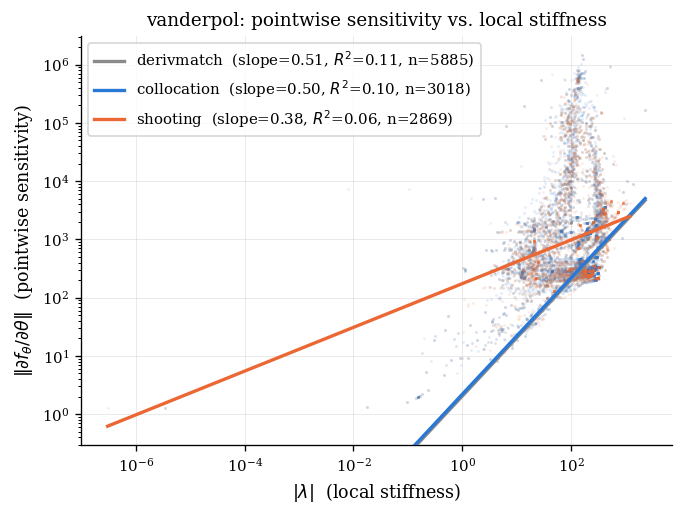

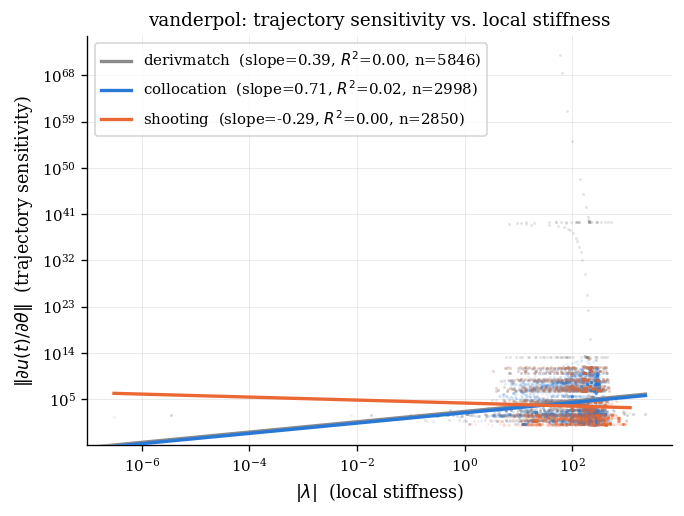

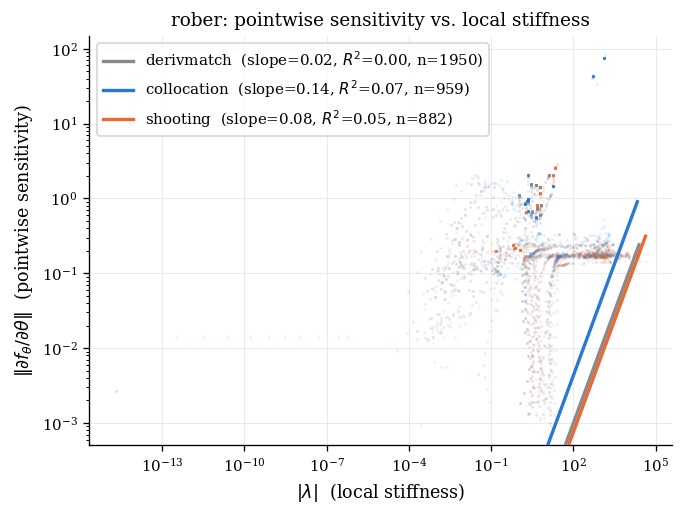

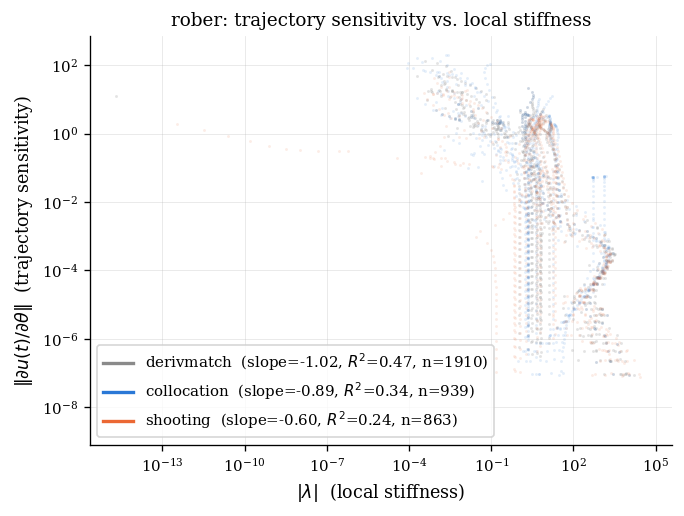

In [6]:
figs = {}
for problem in ("vanderpol", "rober"):
    for m in METRICS:
        figs[(problem, m["key"])] = plot_sensitivity_vs_stiffness(
            sens, problem, m["y_col"], m["ylabel"],
            title=f"{problem}: {m['key']} sensitivity vs. local stiffness",
            save_name=f"{problem}_sensitivity_vs_stiffness_{m['key']}.png",
        )
plt.show()

# Read as: shooting's slope should sit near -1 for the TRAJECTORY metric (the paper's
# O(|z|^-1) barrier for A-stable integrators), while derivmatch/collocation -- which
# never backprop through a chain of solver steps -- should sit near 0 there. The
# POINTWISE metric is a negative control: since it never touches the solver, no stage
# should show barrier-like decay on it, regardless of training method.

In [7]:
table = pd.concat(
    [sensitivity_slope_table(sens, m["y_col"]).assign(metric=m["key"]) for m in METRICS],
    ignore_index=True,
)
table = table[["metric", "problem", "model", "stage", "slope", "intercept", "r2", "n_points"]]
table.to_csv(FIG_DIR.parent / "sensitivity_slope_table.csv", index=False)
table

,metric,problem,model,stage,slope,intercept,r2,n_points
0,pointwise,rober,GELU-scaled,collocation,0.449147,-0.079443,0.731628,459
1,pointwise,rober,GELU-scaled,derivmatch,0.277502,-0.228489,0.629062,950
2,pointwise,rober,GELU-scaled,shooting,0.264639,-0.383002,0.650375,382
3,pointwise,rober,stiff,collocation,0.218716,-1.297302,0.173464,500
4,pointwise,rober,stiff,derivmatch,0.237679,-1.464549,0.231750,1000
5,pointwise,rober,stiff,shooting,0.246022,-1.498420,0.217684,500
6,pointwise,vanderpol,GELU-scaled,collocation,0.754989,1.615578,0.288945,1508
7,pointwise,vanderpol,GELU-scaled,derivmatch,0.713302,1.691853,0.269104,2865
8,pointwise,vanderpol,GELU-scaled,shooting,0.501497,2.114613,0.163352,1359
9,pointwise,vanderpol,stiff,collocation,0.040759,2.889452,0.000449,1510
